In [1]:
!python3.11 -m pip install yfinance numpy pandas scipy matplotlib openpyxl yahooquery statsmodels

In [2]:
#Required Packages
import yfinance as yf
import numpy as np
import pandas as pd
import warnings
from pandas.errors import Pandas4Warning
from scipy.optimize import minimize
from scipy import stats
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from yahooquery import Ticker
from dateutil.relativedelta import relativedelta
import statsmodels.api as sm

In [3]:
#Loading Stocks from given excel sheet
excel_sheet = "stocks.xlsx"
sheet_name = "Sheet1"
ticker_column = "Tickers"

df = pd.read_excel(excel_sheet, sheet_name=sheet_name);
tickers = df[ticker_column].dropna().tolist()

In [4]:
#Pulling data for each ticker
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=365*3)).strftime('%Y-%m-%d')

print(f"Fetching Data for {len(tickers)} tickers")
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)

price_df = data['Close'].dropna(axis=1)
tickers = price_df.columns.tolist()
print(price_df.head())

warnings.filterwarnings('ignore', category=Pandas4Warning)

Fetching Data for 6 tickers


/opt/homebrew/lib/python3.11/site-packages/yfinance/scrapers/history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  6 of 6 completed

Ticker          AROC        CEG        FANG        FRO        NEE        WDS
Date                                                                        
2023-02-23  9.291964  77.293976  124.901085  13.479294  66.780579  19.277615
2023-02-24  9.765039  77.619057  125.589088  13.546878  66.826401  19.162916
2023-02-27  9.640078  76.737808  127.335579  13.929852  66.280357  19.597136
2023-02-28  9.881080  73.330269  124.001373  14.177660  65.514801  19.933039
2023-03-01  9.907857  72.801529  127.564919  13.907325  64.444878  20.383640


# Hierarchical Risk Parity (HRP) Portfolio Optimization

In [5]:
# Importing additional packages
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

In [6]:
def cluster_var(cov, cluster):
    # Getting a sub-covariance matrix the cluster
    cov_slice = cov[np.ix_(cluster, cluster)]

    # Getting the diagonal - lower variance get higher weights since 1/smaller > 1/larger
    diag = np.diag(cov_slice)
    inv_diag = 1.0 / diag

    # Normalizing these weights
    inv_diag = inv_diag / inv_diag.sum()
    
    # Reshape for vector math
    w = inv_diag.reshape(-1, 1)
    
    # Calculating the clusters variance doing w^T * Cov * W
    return float(w.T @ cov_slice @ w)

def get_leaves(cluster_id, Z, n):
    # Base case
    if cluster_id < n:
        return [cluster_id]
        
    # If not, then split tree in half again
    left = int(Z[cluster_id - n, 0])
    right = int(Z[cluster_id - n, 1])

    # Recursively collects the leaves from both sides
    return get_leaves(left, Z, n) + get_leaves(right, Z, n)

def hrp_allocate(cov, Z):
    n = cov.shape[0]
    
    # Initialized same weightings 
    w = np.ones(n)

    def recurse(cluster_id):
        # Base case
        if cluster_id < n:
            return

        # Get child cluster from linkage tree
        left = int(Z[cluster_id - n, 0])
        right = int(Z[cluster_id - n, 1])

        # Retrive the next asset in the cluster
        left_leaves = get_leaves(left, Z, n)
        right_leaves = get_leaves(right, Z, n)

        # Compute the cluster variance
        left_var = cluster_var(cov, left_leaves)
        right_var = cluster_var(cov, right_leaves)

        # Allocate more weighting for the lower-variance cluster
        alpha = right_var / (left_var + right_var)

        # Applying weightings to both sides respectively
        w[left_leaves] *= alpha
        w[right_leaves] *= (1 - alpha)
        
        recurse(left)
        recurse(right)

    # Root node of the dendrogram
    root = 2 * n - 2
    recurse(root)

    # Normalize weights to sum to 1
    return w / w.sum()

/var/folders/7_/138wbpmx02zfdb_585wmqlqc0000gn/T/ipykernel_17629/1295552630.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(w.T @ cov_slice @ w)


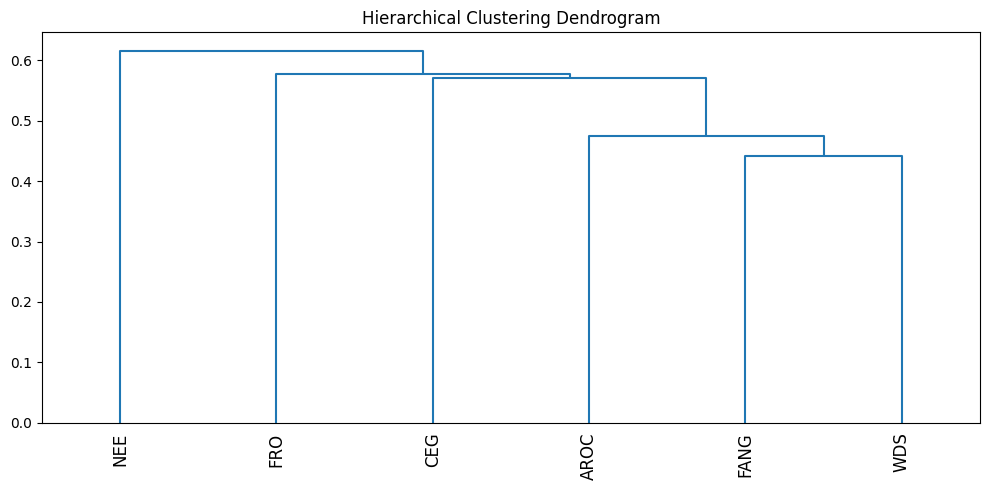

In [7]:
# Calculate percentage returns
returns = price_df.pct_change().dropna()

# Creating a correlation matrix for HERC
corr_matrix = returns.corr()

# Annualized covariance matrix
cov_matrix = returns.cov() * 252

# Converting the correlation matrix to a clustering distance matrix
dist = np.sqrt((1 - corr_matrix.values) / 2)

# Running a hierarchical clustering algorithm 
dist_condensed = squareform(dist, checks = False)
Z = linkage(dist_condensed, method="single")

# Creating fully optimized weights
hrp_weights = hrp_allocate(cov_matrix.values, Z)

# Visualizing the quasi diagram
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=price_df.columns, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram")
plt.tight_layout()
plt.show()

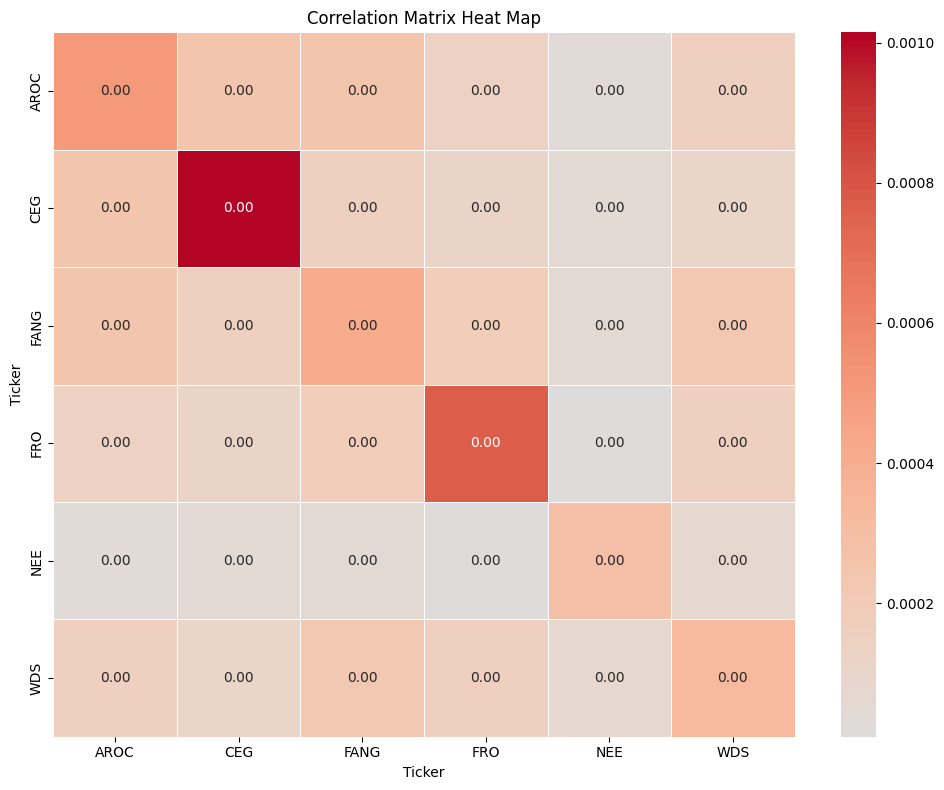

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    returns.cov(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix Heat Map")
plt.tight_layout()
plt.show()

In [9]:
# Adding updated weights to excel in a new column
# Will be used later for testing and visualization
hrp_w = pd.Series(hrp_weights, index=price_df.columns, name="HRP")

df[hrp_w.name] = df[ticker_column].map(hrp_w)

with pd.ExcelWriter(excel_sheet, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df.to_excel(writer, sheet_name=sheet_name, index=False)

print("Added Updated Weights to Excel Sheet")

Added Updated Weights to Excel Sheet


## Multi-Factor Model
Factors will be the TTM Momentum, Price to Book, Earnings Yield, ROE, Debt to equity, and the beta. Combined these are the best suited factors for the finanical sector because it captures the four core factors that matters, Value (finds cheap banks), Quality (separates good banks from bad), Risk (controls downside), and Trend (captures regime persistence).

In [10]:
# Getting data for that will be for R_r+1
def get_forward_return(ticker, start_date, end_date):
    try:
        hist = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            auto_adjust=True,
            progress=False
        )

        if hist is None or len(hist) < 2:
            return np.nan

        if isinstance(hist.columns, pd.MultiIndex):
            close = hist['Close'][ticker] if ticker in hist['Close'].columns else hist['Close'].iloc[:, 0]
        else:
            close = hist['Close']

        start_price = float(close.iloc[0])
        end_price = float(close.iloc[-1])

        return (end_price / start_price) - 1

    except:
        return np.nan


def get_factors_at_date(ticker, as_of_date):
    factors = {}
    stock = yf.Ticker(ticker)

    try:
        hist = stock.history(
            start=as_of_date - timedelta(days=800),
            end=as_of_date
        )

        if len(hist) < 252:
            return None

        # Getting Momentum 
        if len(hist) >= 274:
            current_price = hist['Close'].iloc[-22]
            price_1y_ago = hist['Close'].iloc[-274] 
            factors["M"] = float((current_price - price_1y_ago) / price_1y_ago)
        else:
            factors["M"] = np.nan

        info = stock.info

        factors["PB"] = info.get("priceToBook", np.nan)

        pe = info.get("trailingPE", None)
        factors["EP"] = 1 / pe if pe not in [None, 0] else np.nan

        factors["ROE"] = info.get("returnOnEquity", np.nan)
        factors["DE"] = info.get("debtToEquity", np.nan)
        factors["B"] = info.get("beta", np.nan)

    except:
        return None

    return factors


# Calibrates the model by running a historical backtest
# to identify which stock characteristics were most rewarded by the market so we can weight our current portfolio accordingly.
def build_panel_data(tickers, start_date, end_date, rebalance_freq='ME'):    

    date_range = pd.date_range(start=start_date, end=end_date, freq=rebalance_freq)
    panel_data = []

    for date in date_range:

        forward_date = date + relativedelta(years=1)
        print(date.date())

        for ticker in tickers:

            factors = get_factors_at_date(ticker, date)
            if factors is None:
                continue

            fwd_return = get_forward_return(ticker, date, forward_date)
            if not np.isfinite(fwd_return):
                continue

            panel_data.append({
                'date': date,
                'ticker': ticker,
                'forward_return': float(fwd_return),
                **factors
            })

    return pd.DataFrame(panel_data)


# Calculating z-scores within each time period
def calculate_cross_sectional_zscores(group):

    z = pd.DataFrame(index=group.index)

    def zscore(series, higher_is_better=True):
        std = series.std()
        if pd.notna(std) and std > 0:
            if higher_is_better:
                return (series - series.mean()) / std
            else:
                return (series.mean() - series) / std
        return 0.0

    # Lower is better
    z["Z_PB"] = zscore(group["PB"], higher_is_better=False)
    z["Z_DE"] = zscore(group["DE"], higher_is_better=False)
    z["Z_B"]  = zscore(group["B"],  higher_is_better=False)

    # Higher is better
    z["Z_EP"]  = zscore(group["EP"],  higher_is_better=True)
    z["Z_ROE"] = zscore(group["ROE"], higher_is_better=True)
    z["Z_M"]   = zscore(group["M"],   higher_is_better=True)

    return z.replace([np.inf, -np.inf], np.nan).fillna(0)


# Training on an OLS regression on using the panel data created
# to find optimal factor weights
def train_factor_model(panel_df):

    z_score_list = []

    for date, group in panel_df.groupby('date'):
        z_scores = calculate_cross_sectional_zscores(group)
        z_scores['forward_return'] = group['forward_return'].values
        z_score_list.append(z_scores)

    regression_data = pd.concat(z_score_list, ignore_index=True).dropna()

    X = regression_data[['Z_PB', 'Z_EP', 'Z_ROE', 'Z_DE', 'Z_M', 'Z_B']]
    X = sm.add_constant(X)
    y = regression_data['forward_return']

    return sm.OLS(y, X).fit()


# Maximizing expected return subject to constraints
def optimize_portfolio_weights(predicted_returns, max_weight=0.2):

    n = len(predicted_returns)

    def objective(w):
        return -np.dot(w, predicted_returns.values)

    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    bounds = [(0.0, max_weight)] * n
    w0 = np.ones(n) / n

    result = minimize(objective, w0, method='SLSQP',
                      bounds=bounds, constraints=constraints)

    return pd.Series(result.x, index=predicted_returns.index)


# Applying the trained model to current stock portfolio
def apply_model_to_current_stocks(tickers, model):    

    today = datetime.now()
    current_factors = {}

    for ticker in tickers:
        factors = get_factors_at_date(ticker, today)
        if factors is not None:
            current_factors[ticker] = factors

    factors_df = pd.DataFrame.from_dict(current_factors, orient='index')
    z_scores = calculate_cross_sectional_zscores(factors_df)

    weights = model.params.drop('const')

    z_scores['Predicted_Return'] = (
        z_scores[weights.index] * weights
    ).sum(axis=1) + model.params['const']

    z_scores['Portfolio_Weight'] = optimize_portfolio_weights(
        z_scores['Predicted_Return']
    )

    return z_scores[['Portfolio_Weight']]


# Training period is set to 3 year
train_start = '2023-01-01'
train_end = '2026-01-01'

panel_df = build_panel_data(tickers, train_start, train_end)
model = train_factor_model(panel_df)
portfolio_weights = apply_model_to_current_stocks(tickers, model)

portfolio_weights.sort_values(by='Portfolio_Weight', ascending=False)

2023-01-31
2023-02-28
2023-03-31
2023-04-30
2023-05-31
2023-06-30
2023-07-31
2023-08-31
2023-09-30
2023-10-31
2023-11-30
2023-12-31
2024-01-31
2024-02-29
2024-03-31
2024-04-30
2024-05-31
2024-06-30
2024-07-31
2024-08-31
2024-09-30
2024-10-31
2024-11-30
2024-12-31
2025-01-31
2025-02-28
2025-03-31
2025-04-30
2025-05-31
2025-06-30
2025-07-31
2025-08-31
2025-09-30
2025-10-31
2025-11-30
2025-12-31


,Portfolio_Weight
CEG,0.2
FANG,0.2
NEE,0.2
FRO,0.2
AROC,0.2
WDS,0.0


In [12]:
optimized_w = pd.Series(
    portfolio_weights['Portfolio_Weight'], 
    index=portfolio_weights.index, 
    name="Factored")

df[optimized_w.name] = df[ticker_column].map(optimized_w)

# Write to Excel (this will add the new column while keeping HRP column)
with pd.ExcelWriter(excel_sheet, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df.to_excel(writer, sheet_name=sheet_name, index=False)


In [13]:
def calculate_portfolio_performance(weights, returns, risk_free_rate=0.02):
    portfolio_returns = (returns * weights).sum(axis=1)
    annual_return = portfolio_returns.mean() * 252
    annual_volatility = portfolio_returns.std() * np.sqrt(252)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

    cumulative_returns = (1 + portfolio_returns).cumprod()

    metrics = {
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Portfolio Returns": portfolio_returns,
        "Cumulative Returns": cumulative_returns
    }

    return metrics

def backtest_portfolio(weights, tickers, prices, returns, risk_free_rate=0.02, initial_capital=10000):
    metrics = calculate_portfolio_performance(weights, returns, risk_free_rate)
    portfolio_value = initial_capital * metrics["Cumulative Returns"]

    results = {
        "weights": weights,
        "tickers": tickers,
        "metrics": metrics,
        "portfolio_value": portfolio_value,
        "initial_capital": initial_capital
    }

    return results

def downside_deviation(r: pd.Series, mar_annual: float = 0.0, trading_days: int = 252) -> float:
    r = r.dropna()
    if len(r) == 0: return np.nan
    mar_d = mar_annual / trading_days
    downside = np.minimum(r - mar_d, 0.0)
    return np.sqrt(np.mean(downside**2)) * np.sqrt(trading_days)

def sortino_ratio(r: pd.Series, rf_annual: float = 0.045, mar_annual: float = 0.0, trading_days: int = 252) -> float:
    r = r.dropna()
    if len(r) < 2: return np.nan
    ann_ret = r.mean() * trading_days
    dd = downside_deviation(r, mar_annual=mar_annual, trading_days=trading_days)
    return np.nan if (not np.isfinite(dd) or dd <= 0) else (ann_ret - rf_annual) / dd

def summarize_and_plot(results_dict: dict, rf_annual: float = 0.045, trading_days: int = 252, mar_annual: float = 0.0):
    # common date index
    common = None
    for res in results_dict.values():
        idx = res["portfolio_value"].dropna().index
        common = idx if common is None else common.intersection(idx)
    if common is None or len(common) == 0:
        raise ValueError("No overlapping dates across strategies.")

    # cumulative % returns (0..100 scale)
    cum_pct = pd.DataFrame({
        name: (res["portfolio_value"].reindex(common) / res["initial_capital"] - 1.0) * 100
        for name, res in results_dict.items()
    })

    # summary metrics
    rows = []
    for name, res in results_dict.items():
        m = res["metrics"]
        ann_ret = float(m["Annual Return"])
        ann_vol = float(m["Annual Volatility"])
        risk_adj = (ann_ret - rf_annual) / ann_vol if ann_vol > 0 else np.nan

        port_rets = m["Portfolio Returns"]
        sortino = sortino_ratio(
            port_rets,
            rf_annual=rf_annual,
            mar_annual=mar_annual,
            trading_days=trading_days
        )

        rows.append({
            "Strategy": name,
            "Annual Return": ann_ret,
            "Annual Vol": ann_vol,
            "Risk Adj (Excess/Vol)": risk_adj,
            "Sortino": sortino
        })

    summary_df = pd.DataFrame(rows).set_index("Strategy")

    # format for display table
    disp = summary_df.copy()
    disp["Annual Return"] = disp["Annual Return"].map(lambda x: f"{x:.2%}" if np.isfinite(x) else "—")
    disp["Annual Vol"] = disp["Annual Vol"] .map(lambda x: f"{x:.2%}" if np.isfinite(x) else "—")
    disp["Risk Adj (Excess/Vol)"] = disp["Risk Adj (Excess/Vol)"].map(lambda x: f"{x:.3f}" if np.isfinite(x) else "—")
    disp["Sortino"] = disp["Sortino"].map(lambda x: f"{x:.3f}" if np.isfinite(x) else "—")

    colors = {'Before': '#7f212f', 'Factored': '#c2253c', 'HRP': '#300f19'}

    fig = plt.figure(figsize=(16, 5))

    ax1 = fig.add_subplot(1, 2, 1)
    cum_pct.plot(
        ax=ax1,
        linewidth=2.2,
        color=[colors.get(c, "#1f77b4") for c in cum_pct.columns]
    )

    ax1.set_title("Cumulative Returns (All Strategies)", fontsize=13, fontweight="bold")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Cumulative Return (%)")
    ax1.legend(frameon=False)
    ax1.grid(False)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.axis("off")

    tbl = ax2.table(
        cellText=disp.values,
        rowLabels=disp.index,
        colLabels=disp.columns,
        cellLoc="center",
        loc="center",
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)
    tbl.scale(1.1, 1.6)

    # table styling
    for (row, col), cell in tbl.get_celld().items():
        # header row
        if row == 0:
            cell.set_facecolor("#7f212f")
            cell.set_text_props(color="#FFFFFF")

        # first column (strategy names)
        if col == -1:
            cell.set_facecolor("#7f212f")
            cell.set_text_props(weight="bold", color="#FFFFFF")

        # soft borders
        cell.set_edgecolor("#7f212f")

    ax2.set_title("Performance Summary", fontsize=13, fontweight="bold")

    plt.tight_layout()
    plt.show()
    cum_pct.index = cum_pct.index.date
    cum_pct.to_excel("portfolio_cumulative_returns.xlsx")
    return summary_df, cum_pct


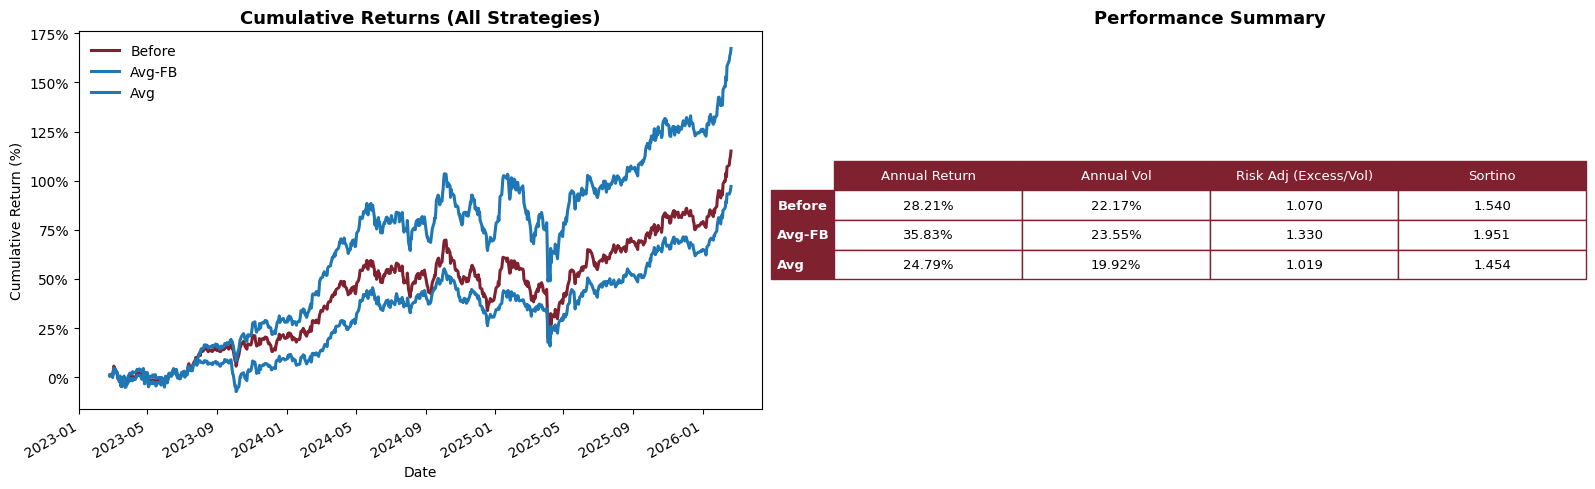

In [17]:
before_results = backtest_portfolio(df["Before"][:7].to_numpy(), tickers, price_df, returns, risk_free_rate=0.045, initial_capital=10000)
#avg_results = backtest_portfolio(df["Average"][:7].to_numpy(), tickers, price_df, returns, risk_free_rate=0.045, initial_capital=10000)
hrp_results    = backtest_portfolio(hrp_w, tickers, price_df, returns, risk_free_rate=0.045, initial_capital=10000)
factor_results = backtest_portfolio(optimized_w, tickers, price_df, returns, risk_free_rate=0.045, initial_capital=10000)
#bl_results    = backtest_portfolio(df["Avg-FB"][:7].to_numpy(), tickers, price_df, returns, risk_free_rate=0.045, initial_capital=10000)
#mv_results    = backtest_portfolio(df["MV"][:7].to_numpy(), tickers, price_df, returns, risk_free_rate=0.045, initial_capital=10000)

results_dict = {
    "Before": before_results,
    "Avg-FB":factor_results,
    "Avg" :hrp_results
    #"Factored": factor_results,
    #"HRP": hrp_results,
    #"MV": mv_results,
    #"Avg": avg_results
}

stats = summarize_and_plot(results_dict, rf_annual=0.045, trading_days=252, mar_annual=0.0)